# Exploratory Data Analysis
- Data loading & inspection
- Data quality checks
- Univariate & bivariate analysis
- Customer demographics
- Transaction patterns
- Product analysis
- Churn insights
- Geographic analysis
- Business insights summary

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='husl')
os.makedirs('../output', exist_ok=True)

## 2. Load Datasets

In [2]:
customers    = pd.read_csv('../data/Customers.csv')
transactions = pd.read_csv('../data/Transactions.csv')
products     = pd.read_csv('../data/Products.csv')

transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])

print(f"Customers    : {customers.shape}")
print(f"Transactions : {transactions.shape}")
print(f"Products     : {products.shape}")

Customers    : (5500, 23)
Transactions : (55000, 11)
Products     : (500, 12)


## 3. Data Inspection

In [3]:
print("CUSTOMERS")
print(list(customers.columns))
customers.head()

CUSTOMERS
['customer_id', 'age', 'gender', 'state', 'city', 'income_level', 'top_category', 'device_type', 'acquisition_channel', 'loyalty_tier', 'session_frequency', 'avg_session_duration', 'cart_abandonment_rate', 'returns_ratio', 'discount_dependency', 'avg_order_value', 'frequency', 'seasonal_spike_factor', 'monetary_value', 'time_between_purchases', 'recency', 'net_promoter_score', 'churn']


,customer_id,age,gender,state,city,income_level,top_category,device_type,acquisition_channel,loyalty_tier,...,returns_ratio,discount_dependency,avg_order_value,frequency,seasonal_spike_factor,monetary_value,time_between_purchases,recency,net_promoter_score,churn
0,C00001,57,Female,Telangana,Hyderabad,High,Fashion,Mobile,Organic Search,Prime,...,0.34,Medium,4268,8,1.13,38583,46,73,41,0
1,C00002,57,Female,Maharashtra,Mumbai,Medium,Beauty,Desktop,Organic Search,Non-Prime,...,0.08,High,1415,2,1.11,3141,182,280,32,0
2,C00003,34,Male,Telangana,Hyderabad,Medium,Electronics,Mobile,Influencer,Prime,...,0.06,Medium,16803,8,1.21,162653,46,24,81,0
3,C00004,34,Male,Karnataka,Mysuru,Medium,Books,Mobile,Organic Search,Non-Prime,...,0.04,Medium,908,1,1.11,1008,365,529,25,1
4,C00005,35,Female,Kerala,Kochi,Low,Home & Kitchen,Mobile,Influencer,Prime,...,0.09,Medium,2899,9,1.06,27656,41,49,77,0


In [4]:
print("TRANSACTIONS")
print(list(transactions.columns))
transactions.head()

TRANSACTIONS
['transaction_id', 'customer_id', 'product_id', 'transaction_date', 'quantity', 'price_per_unit', 'discount_percent', 'total_amount', 'category', 'device_type', 'payment_method']


,transaction_id,customer_id,product_id,transaction_date,quantity,price_per_unit,discount_percent,total_amount,category,device_type,payment_method
0,TXN000001,C04887,P1077,2023-10-25,5,2999,9,13645.45,Electronics,Mobile,UPI
1,TXN000002,C02572,P1350,2023-08-09,5,299,5,1420.25,Grocery,Mobile,Debit Card
2,TXN000003,C01713,P1412,2025-07-12,1,1499,14,1289.14,Home & Kitchen,Mobile,Debit Card
3,TXN000004,C04688,P1017,2023-04-23,3,249999,15,637497.45,Electronics,Mobile,UPI
4,TXN000005,C00727,P1317,2023-10-25,1,799,12,703.12,Home & Kitchen,Desktop,Debit Card


In [5]:
print("PRODUCTS")
print(list(products.columns))
products.head()

PRODUCTS
['product_id', 'product_name', 'brand', 'product_category', 'mrp', 'stock_quantity', 'seasonality_score', 'average_daily_sales', 'conversion_rate', 'rating', 'number_of_reviews', 'is_prime_eligible']


,product_id,product_name,brand,product_category,mrp,stock_quantity,seasonality_score,average_daily_sales,conversion_rate,rating,number_of_reviews,is_prime_eligible
0,P1001,Apple iPhone 17 Pro,Apple,Electronics,129999,85,0.72,38.5,4.6,4.8,12450,Yes
1,P1002,Apple iPhone 16,Apple,Electronics,89999,120,0.68,31.2,4.2,4.7,10221,Yes
2,P1003,Apple AirPods Pro (2nd Gen),Apple,Electronics,24999,200,0.65,44.7,6.1,4.7,8743,Yes
3,P1004,Apple Watch Series 10,Apple,Electronics,45999,75,0.59,18.6,3.9,4.6,5120,Yes
4,P1005,Apple MacBook Air M3,Apple,Electronics,134900,40,0.48,9.5,2.4,4.8,3290,Yes


## 4. Data Quality Report

In [6]:
def quality_report(df, name):
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Shape      : {df.shape[0]:,} rows × {df.shape[1]} cols")
    print(f"  Nulls      : {df.isnull().sum().sum()}")
    print(f"  Duplicates : {df.duplicated().sum()}")
    print(f"  Dtypes     :\n{df.dtypes.value_counts().to_string()}")

quality_report(customers,    "Customers")
quality_report(transactions, "Transactions")
quality_report(products,     "Products")


  Customers
  Shape      : 5,500 rows × 23 cols
  Nulls      : 0
  Duplicates : 0
  Dtypes     :
object     10
int64       9
float64     4

  Transactions
  Shape      : 55,000 rows × 11 cols
  Nulls      : 0
  Duplicates : 0
  Dtypes     :
object            6
int64             3
datetime64[ns]    1
float64           1

  Products
  Shape      : 500 rows × 12 cols
  Nulls      : 0
  Duplicates : 0
  Dtypes     :
object     5
float64    4
int64      3


In [7]:
# Descriptive statistics
print("Customers — Numeric Stats:")
customers.describe().T

Customers — Numeric Stats:


,count,mean,std,min,25%,50%,75%,max
age,5500.0,38.402364,12.190213,18.00,28.00,38.00,49.00,59.00
session_frequency,5500.0,16.191273,7.514946,3.00,10.00,16.00,23.00,29.00
avg_session_duration,5500.0,6.119273,4.070308,2.00,3.40,4.70,6.70,18.00
cart_abandonment_rate,5500.0,0.252905,0.113685,0.05,0.16,0.24,0.35,0.50
returns_ratio,5500.0,0.105296,0.086452,0.01,0.04,0.07,0.13,0.35
avg_order_value,5500.0,5590.096727,7570.402079,333.00,1489.00,2619.00,6490.50,48036.00
frequency,5500.0,5.358909,6.541397,1.00,1.00,4.00,7.00,47.00
seasonal_spike_factor,5500.0,1.200398,0.086489,1.05,1.13,1.20,1.27,1.35
monetary_value,5500.0,35410.939636,87087.429409,359.00,3951.75,11970.00,32165.75,2191431.00
time_between_purchases,5500.0,173.065818,142.195454,8.00,52.00,91.00,365.00,365.00


In [8]:
print("Transactions — Numeric Stats:")
transactions.describe().T

Transactions — Numeric Stats:


,count,mean,min,25%,50%,75%,max,std
transaction_date,55000,2024-06-30 04:52:36.479999744,2023-01-01 00:00:00,2023-09-28 18:00:00,2024-06-28 00:00:00,2025-04-03 00:00:00,2025-12-31 00:00:00,NaN
quantity,55000.0,3.015418,1.0,2.0,3.0,4.0,5.0,1.40939
price_per_unit,55000.0,16393.102527,149.0,520.0,999.0,3999.0,499999.0,50515.326714
discount_percent,55000.0,13.222691,0.0,7.0,12.0,19.0,30.0,7.63014
total_amount,55000.0,42874.085967,107.28,1216.26,2622.36,10498.6875,2474995.05,148339.181114


In [9]:
print("Products — Numeric Stats:")
products.describe().T

Products — Numeric Stats:


,count,mean,std,min,25%,50%,75%,max
mrp,500.0,29265.20400,65376.852439,149.00,799.00,2999.00,17999.00,499999.00
stock_quantity,500.0,171.74000,89.291064,6.00,90.00,190.00,240.00,420.00
seasonality_score,500.0,0.63404,0.096735,0.33,0.57,0.67,0.71,0.77
average_daily_sales,500.0,28.25120,13.486317,0.80,18.35,29.60,38.40,71.50
conversion_rate,500.0,4.33820,1.444678,0.40,3.50,4.50,5.40,8.10
rating,500.0,4.52220,0.160682,4.10,4.40,4.50,4.60,4.90
number_of_reviews,500.0,4123.92800,4741.038608,120.00,1428.00,2500.00,4200.75,31000.00


## 5. Customer Demographics — Univariate Analysis

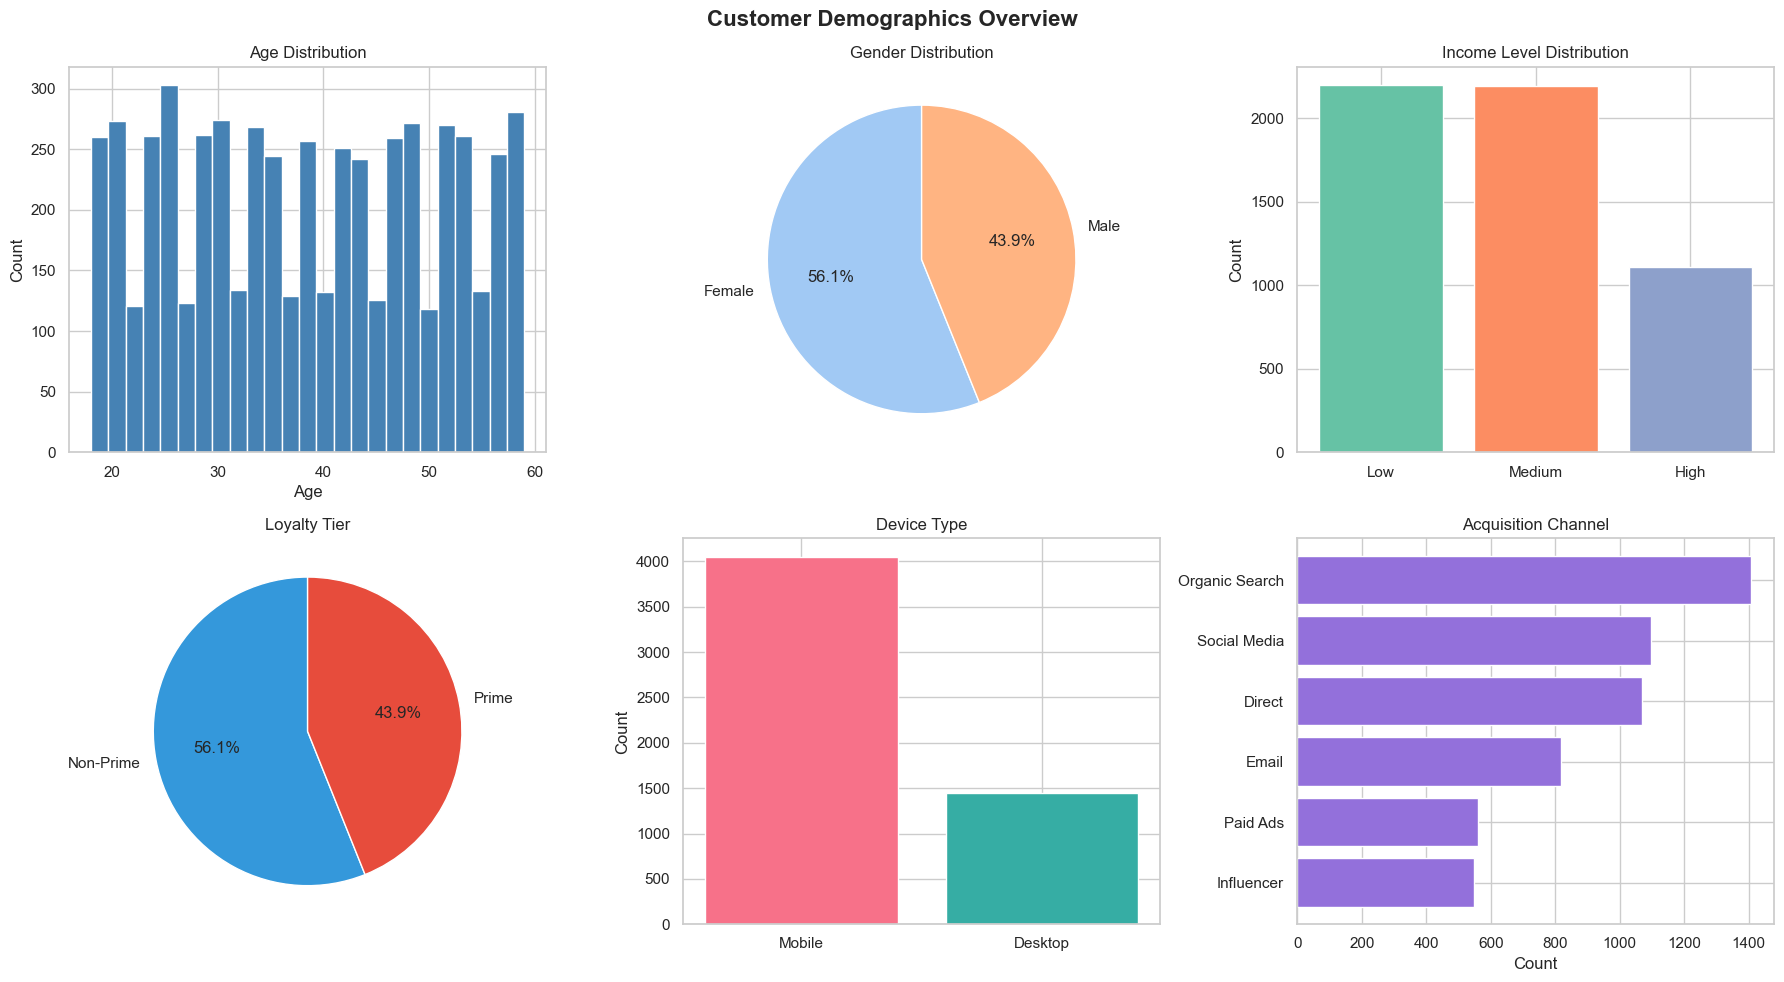

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Customer Demographics Overview', fontsize=16, fontweight='bold')

# Age distribution
axes[0,0].hist(customers['age'], bins=25, color='steelblue', edgecolor='white')
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Count')

# Gender
g = customers['gender'].value_counts()
axes[0,1].pie(g, labels=g.index, autopct='%1.1f%%',
              colors=sns.color_palette('pastel'), startangle=90)
axes[0,1].set_title('Gender Distribution')

# Income level
inc = customers['income_level'].value_counts()
axes[0,2].bar(inc.index, inc.values, color=sns.color_palette('Set2', len(inc)))
axes[0,2].set_title('Income Level Distribution')
axes[0,2].set_ylabel('Count')

# Loyalty tier
lt = customers['loyalty_tier'].value_counts()
axes[1,0].pie(lt, labels=lt.index, autopct='%1.1f%%',
              colors=['#3498db','#e74c3c'], startangle=90)
axes[1,0].set_title('Loyalty Tier')

# Device type
dt = customers['device_type'].value_counts()
axes[1,1].bar(dt.index, dt.values, color=sns.color_palette('husl', len(dt)))
axes[1,1].set_title('Device Type')
axes[1,1].set_ylabel('Count')

# Acquisition channel
ac = customers['acquisition_channel'].value_counts()
axes[1,2].barh(ac.index[::-1], ac.values[::-1], color='mediumpurple')
axes[1,2].set_title('Acquisition Channel')
axes[1,2].set_xlabel('Count')

plt.tight_layout()
plt.savefig('../output/eda_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Customer Behavioral Analysis

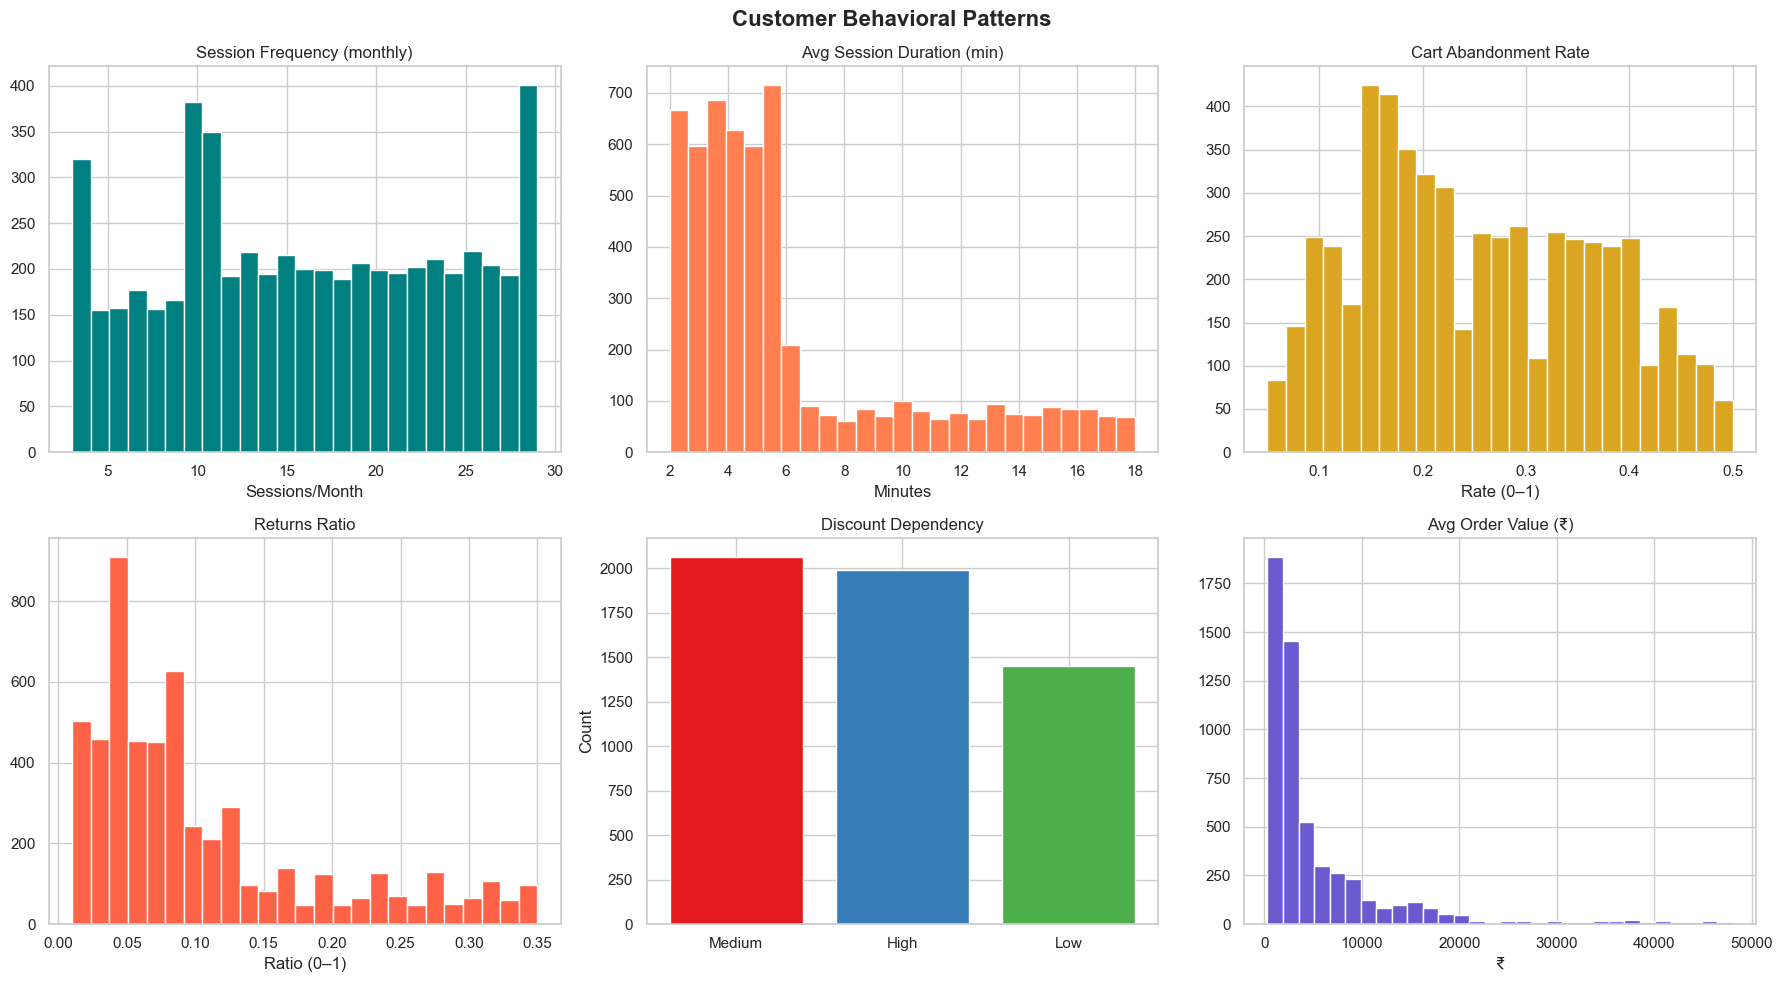

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Customer Behavioral Patterns', fontsize=16, fontweight='bold')

# Session frequency
axes[0,0].hist(customers['session_frequency'], bins=25, color='teal', edgecolor='white')
axes[0,0].set_title('Session Frequency (monthly)')
axes[0,0].set_xlabel('Sessions/Month')

# Avg session duration
axes[0,1].hist(customers['avg_session_duration'], bins=25, color='coral', edgecolor='white')
axes[0,1].set_title('Avg Session Duration (min)')
axes[0,1].set_xlabel('Minutes')

# Cart abandonment rate
axes[0,2].hist(customers['cart_abandonment_rate'], bins=25, color='goldenrod', edgecolor='white')
axes[0,2].set_title('Cart Abandonment Rate')
axes[0,2].set_xlabel('Rate (0–1)')

# Returns ratio
axes[1,0].hist(customers['returns_ratio'], bins=25, color='tomato', edgecolor='white')
axes[1,0].set_title('Returns Ratio')
axes[1,0].set_xlabel('Ratio (0–1)')

# Discount dependency
dd = customers['discount_dependency'].value_counts()
axes[1,1].bar(dd.index, dd.values, color=sns.color_palette('Set1', len(dd)))
axes[1,1].set_title('Discount Dependency')
axes[1,1].set_ylabel('Count')

# Avg order value
axes[1,2].hist(customers['avg_order_value'], bins=30, color='slateblue', edgecolor='white')
axes[1,2].set_title('Avg Order Value (₹)')
axes[1,2].set_xlabel('₹')

plt.tight_layout()
plt.savefig('../output/eda_behavior.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. RFM Distribution

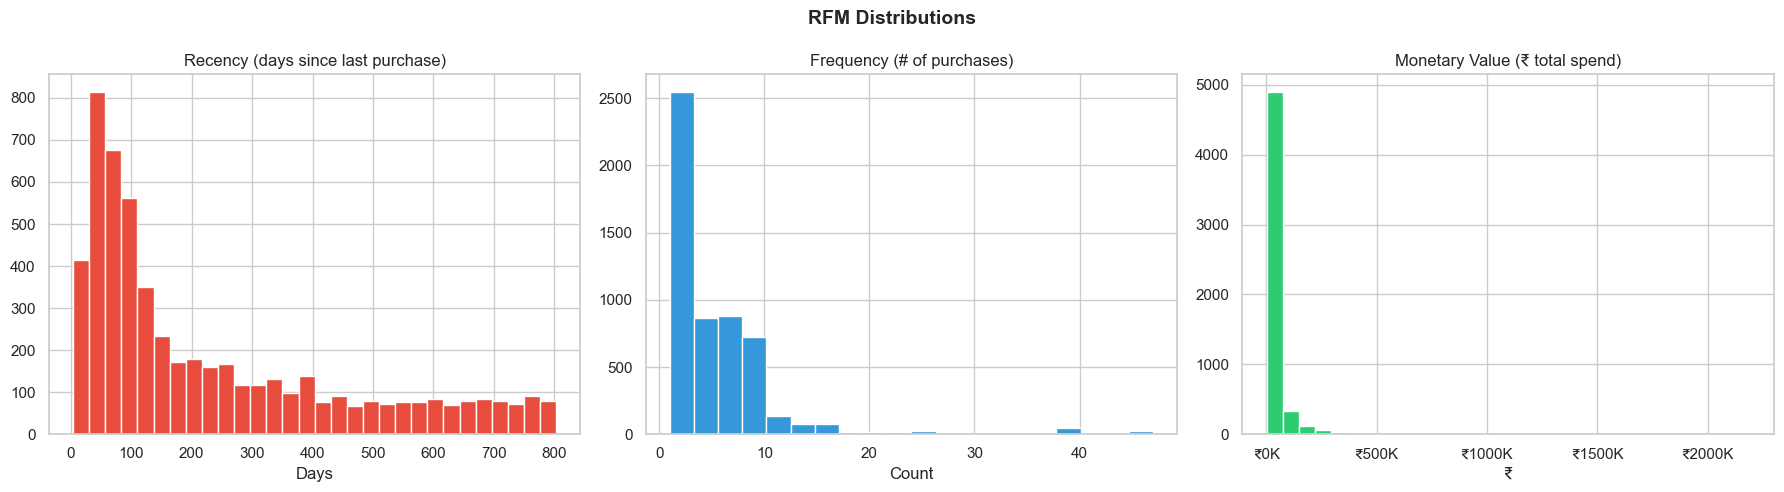

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RFM Distributions', fontsize=14, fontweight='bold')

axes[0].hist(customers['recency'], bins=30, color='#e74c3c', edgecolor='white')
axes[0].set_title('Recency (days since last purchase)')
axes[0].set_xlabel('Days')

axes[1].hist(customers['frequency'], bins=20, color='#3498db', edgecolor='white')
axes[1].set_title('Frequency (# of purchases)')
axes[1].set_xlabel('Count')

axes[2].hist(customers['monetary_value'], bins=30, color='#2ecc71', edgecolor='white')
axes[2].set_title('Monetary Value (₹ total spend)')
axes[2].set_xlabel('₹')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1e3:.0f}K'))

plt.tight_layout()
plt.savefig('../output/eda_rfm_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Transaction Analysis

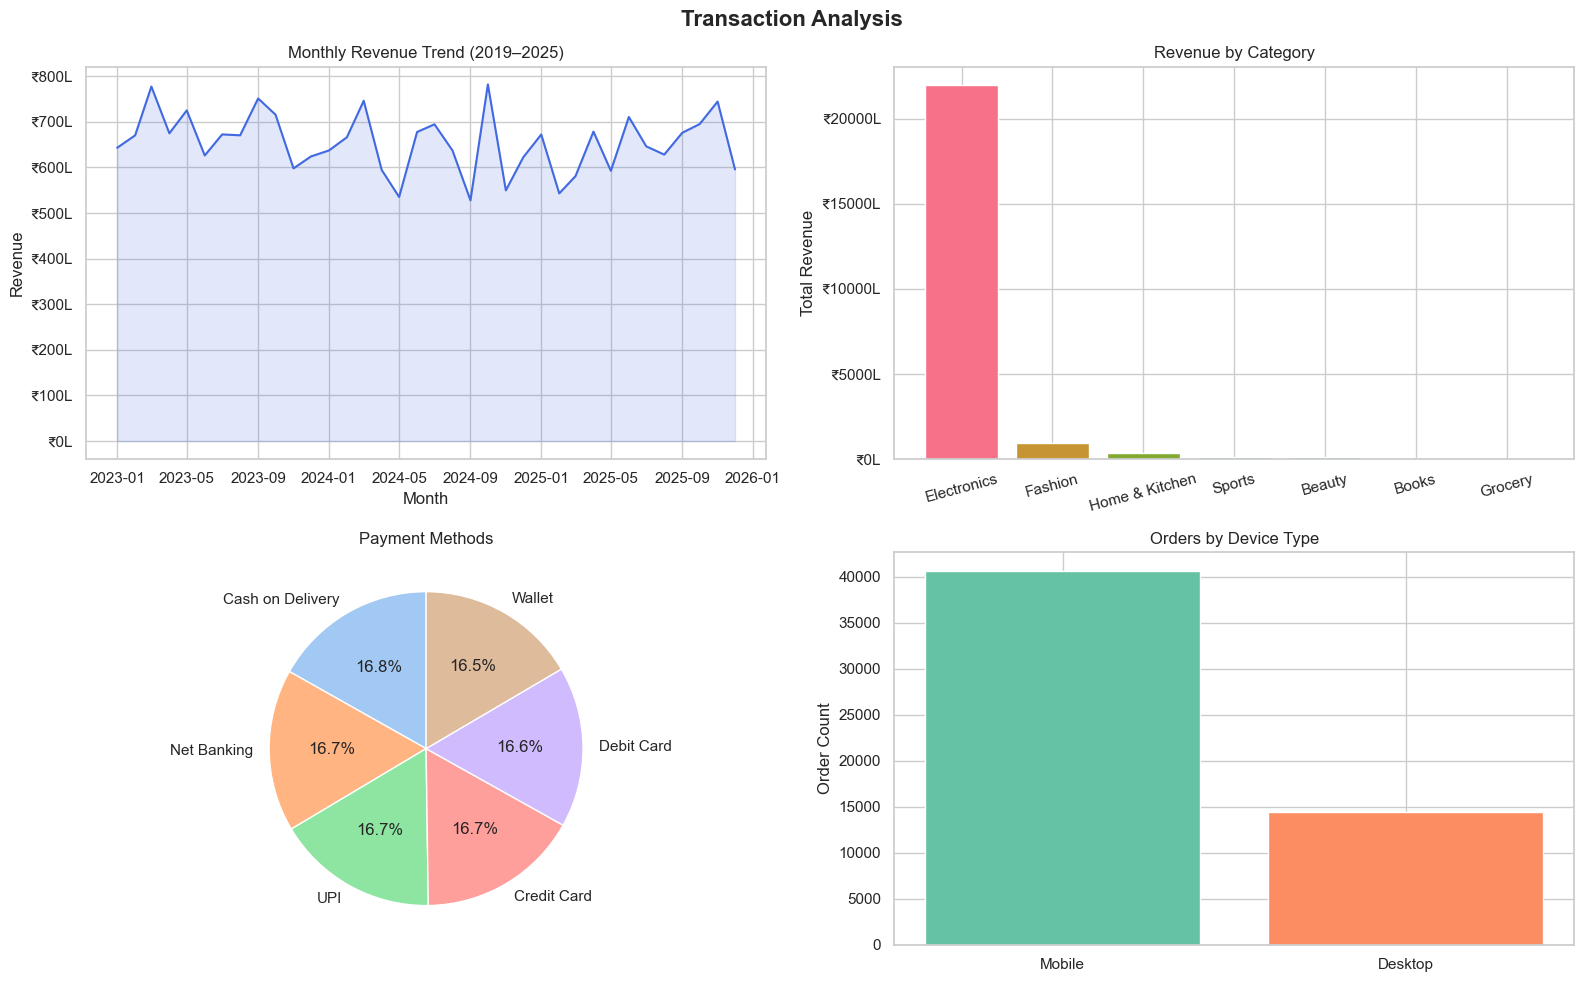

In [13]:
# Monthly revenue trend
monthly_rev = (transactions
    .groupby(transactions['transaction_date'].dt.to_period('M'))['total_amount']
    .sum().reset_index())
monthly_rev.columns = ['month', 'revenue']
monthly_rev['month_dt'] = monthly_rev['month'].dt.to_timestamp()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Transaction Analysis', fontsize=16, fontweight='bold')

# Monthly revenue trend
axes[0,0].plot(monthly_rev['month_dt'], monthly_rev['revenue'],
               color='royalblue', linewidth=1.5)
axes[0,0].fill_between(monthly_rev['month_dt'], monthly_rev['revenue'], alpha=0.15, color='royalblue')
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1e5:.0f}L'))
axes[0,0].set_title('Monthly Revenue Trend (2019–2025)')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Revenue')

# Revenue by category
cat_rev = transactions.groupby('category')['total_amount'].sum().sort_values(ascending=False)
axes[0,1].bar(cat_rev.index, cat_rev.values, color=sns.color_palette('husl', len(cat_rev)))
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1e5:.0f}L'))
axes[0,1].set_title('Revenue by Category')
axes[0,1].set_ylabel('Total Revenue')
axes[0,1].tick_params(axis='x', rotation=15)

# Payment methods
pay = transactions['payment_method'].value_counts()
axes[1,0].pie(pay, labels=pay.index, autopct='%1.1f%%',
              colors=sns.color_palette('pastel'), startangle=90)
axes[1,0].set_title('Payment Methods')

# Orders by device type
dev = transactions['device_type'].value_counts()
axes[1,1].bar(dev.index, dev.values, color=sns.color_palette('Set2', len(dev)))
axes[1,1].set_title('Orders by Device Type')
axes[1,1].set_ylabel('Order Count')

plt.tight_layout()
plt.savefig('../output/eda_transactions.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Product Analysis

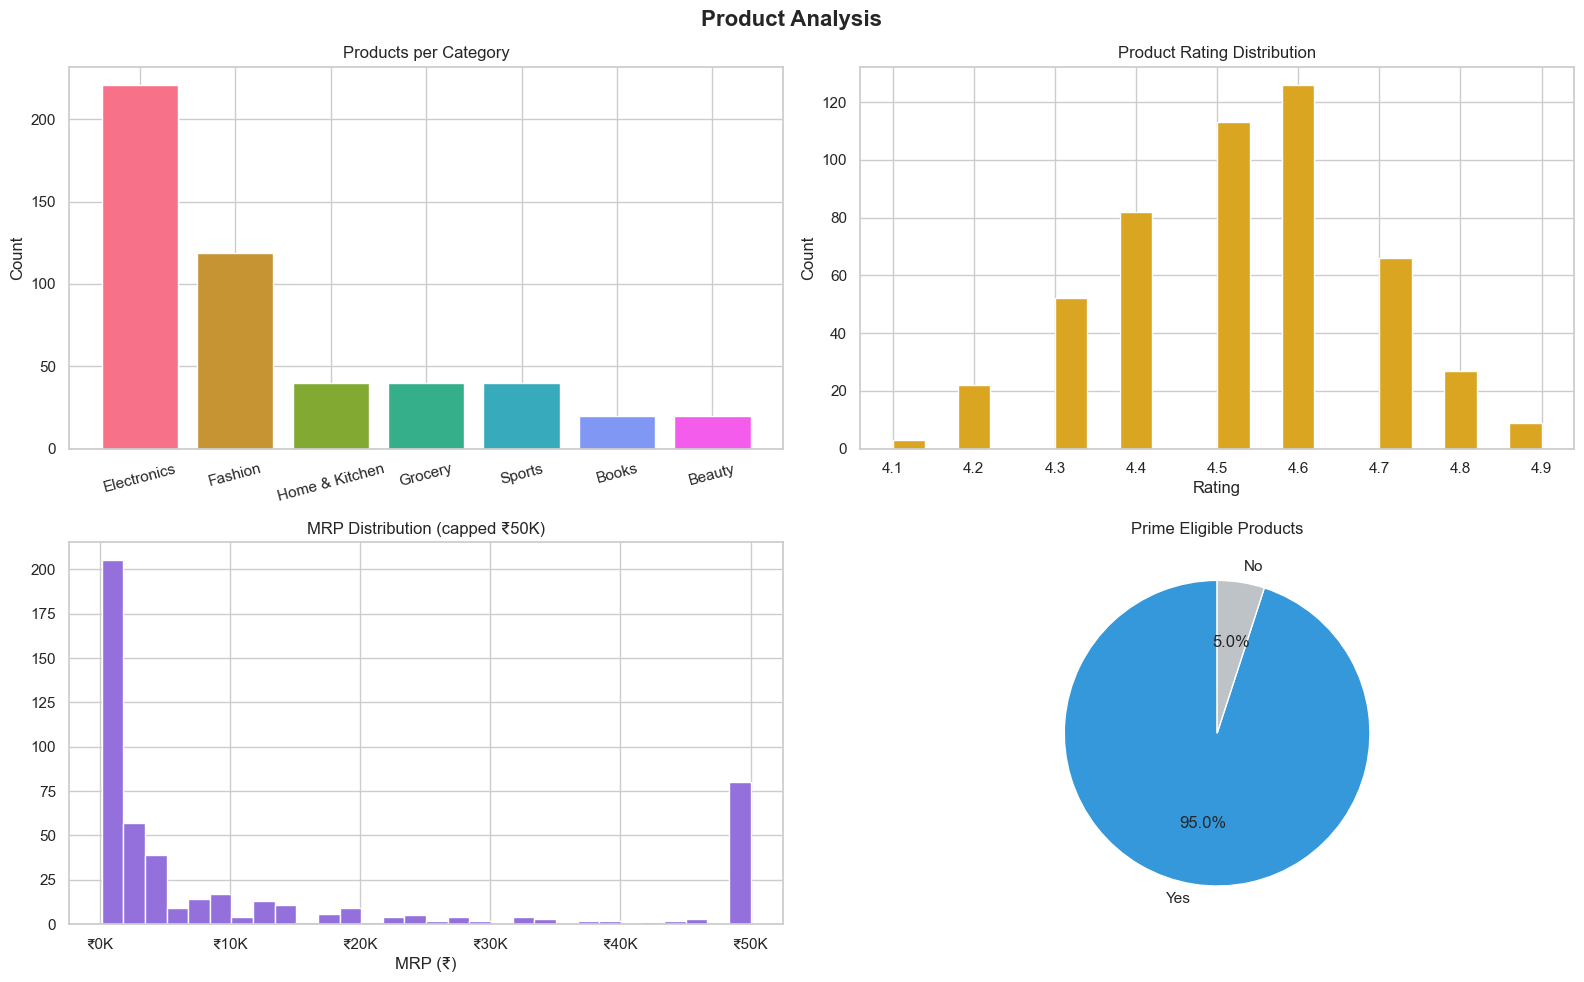

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Product Analysis', fontsize=16, fontweight='bold')

# Category distribution
cat_prod = products['product_category'].value_counts()
axes[0,0].bar(cat_prod.index, cat_prod.values, color=sns.color_palette('husl', len(cat_prod)))
axes[0,0].set_title('Products per Category')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=15)

# Rating distribution
axes[0,1].hist(products['rating'], bins=20, color='goldenrod', edgecolor='white')
axes[0,1].set_title('Product Rating Distribution')
axes[0,1].set_xlabel('Rating')
axes[0,1].set_ylabel('Count')

# MRP distribution
axes[1,0].hist(products['mrp'].clip(upper=50000), bins=30, color='mediumpurple', edgecolor='white')
axes[1,0].set_title('MRP Distribution (capped ₹50K)')
axes[1,0].set_xlabel('MRP (₹)')
axes[1,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1e3:.0f}K'))

# Prime eligible
pe = products['is_prime_eligible'].value_counts()
axes[1,1].pie(pe, labels=pe.index, autopct='%1.1f%%',
              colors=['#3498db','#bdc3c7'], startangle=90)
axes[1,1].set_title('Prime Eligible Products')

plt.tight_layout()
plt.savefig('../output/eda_products.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Churn Analysis — Bivariate

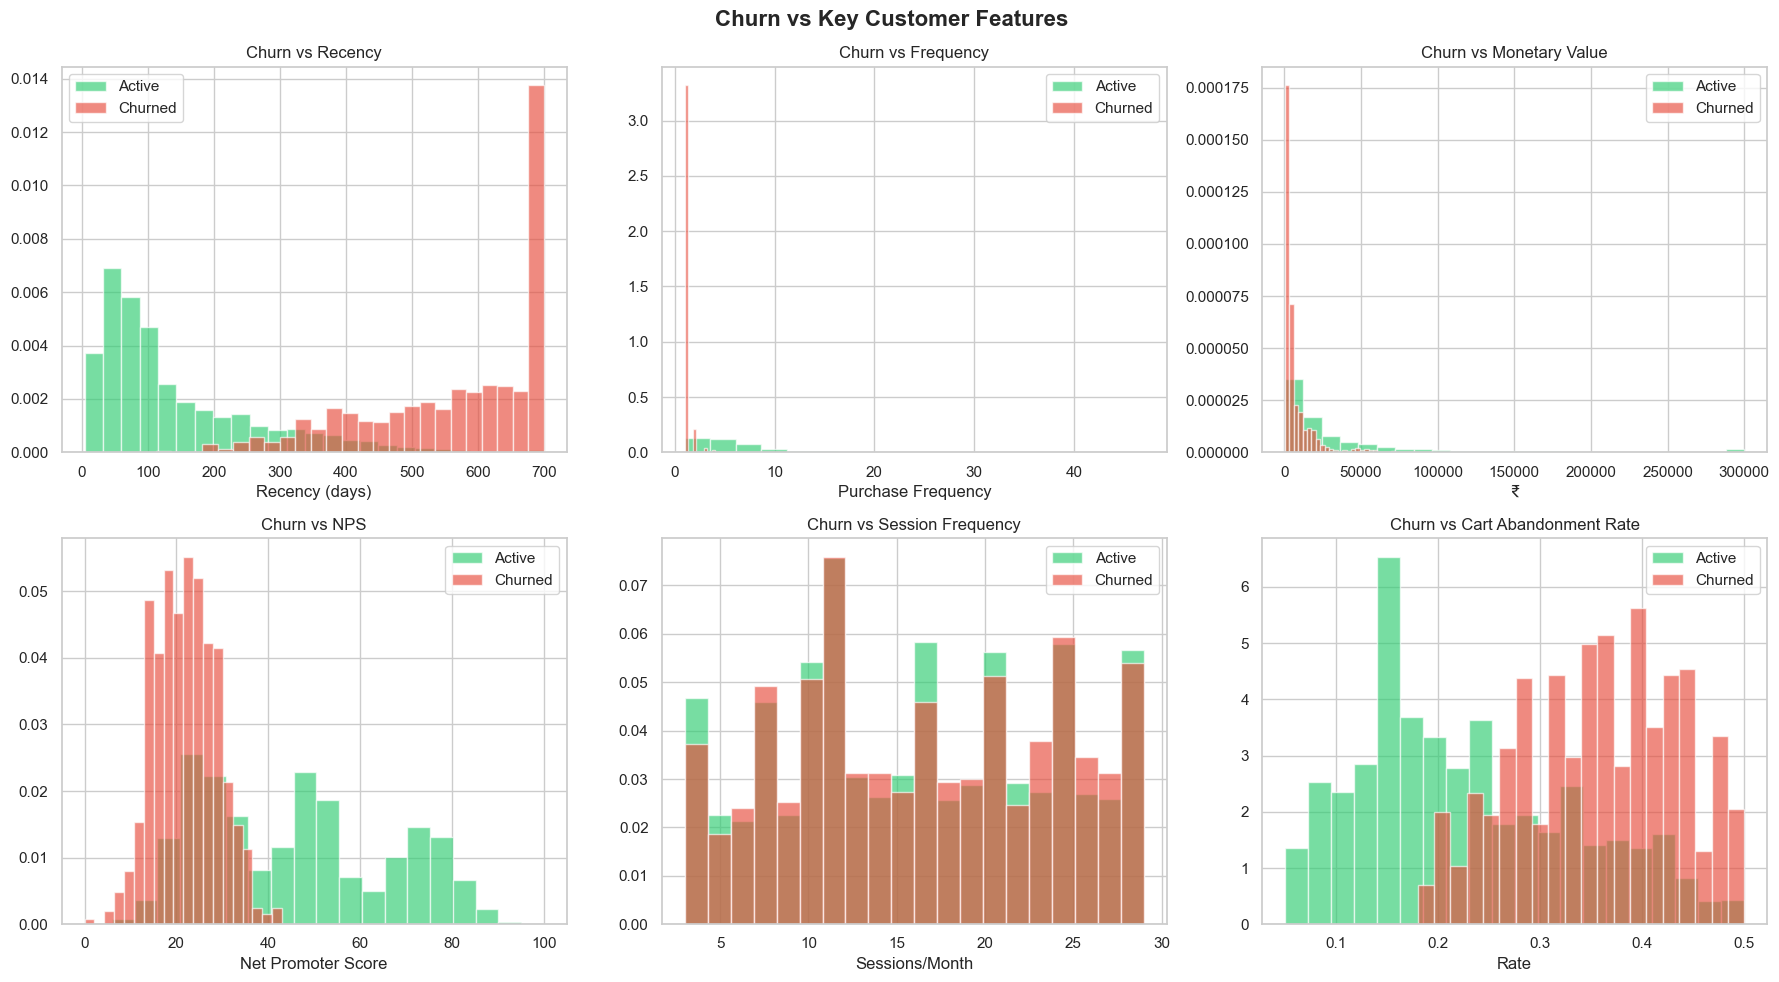

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Churn vs Key Customer Features', fontsize=16, fontweight='bold')

churn_labels = {0: 'Active', 1: 'Churned'}
colors_churn = {0: '#2ecc71', 1: '#e74c3c'}

# Recency
for label, color in colors_churn.items():
    mask = customers['churn'] == label
    axes[0,0].hist(customers.loc[mask, 'recency'].clip(upper=700), bins=25,
                   alpha=0.65, label=churn_labels[label], color=color, density=True)
axes[0,0].set_title('Churn vs Recency')
axes[0,0].set_xlabel('Recency (days)')
axes[0,0].legend()

# Frequency
for label, color in colors_churn.items():
    mask = customers['churn'] == label
    axes[0,1].hist(customers.loc[mask, 'frequency'], bins=18,
                   alpha=0.65, label=churn_labels[label], color=color, density=True)
axes[0,1].set_title('Churn vs Frequency')
axes[0,1].set_xlabel('Purchase Frequency')
axes[0,1].legend()

# Monetary value
for label, color in colors_churn.items():
    mask = customers['churn'] == label
    axes[0,2].hist(customers.loc[mask, 'monetary_value'].clip(upper=300000), bins=25,
                   alpha=0.65, label=churn_labels[label], color=color, density=True)
axes[0,2].set_title('Churn vs Monetary Value')
axes[0,2].set_xlabel('₹')
axes[0,2].legend()

# NPS
for label, color in colors_churn.items():
    mask = customers['churn'] == label
    axes[1,0].hist(customers.loc[mask, 'net_promoter_score'], bins=20,
                   alpha=0.65, label=churn_labels[label], color=color, density=True)
axes[1,0].set_title('Churn vs NPS')
axes[1,0].set_xlabel('Net Promoter Score')
axes[1,0].legend()

# Session frequency
for label, color in colors_churn.items():
    mask = customers['churn'] == label
    axes[1,1].hist(customers.loc[mask, 'session_frequency'], bins=20,
                   alpha=0.65, label=churn_labels[label], color=color, density=True)
axes[1,1].set_title('Churn vs Session Frequency')
axes[1,1].set_xlabel('Sessions/Month')
axes[1,1].legend()

# Cart abandonment
for label, color in colors_churn.items():
    mask = customers['churn'] == label
    axes[1,2].hist(customers.loc[mask, 'cart_abandonment_rate'], bins=20,
                   alpha=0.65, label=churn_labels[label], color=color, density=True)
axes[1,2].set_title('Churn vs Cart Abandonment Rate')
axes[1,2].set_xlabel('Rate')
axes[1,2].legend()

plt.tight_layout()
plt.savefig('../output/eda_churn_bivariate.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Correlation Heatmap

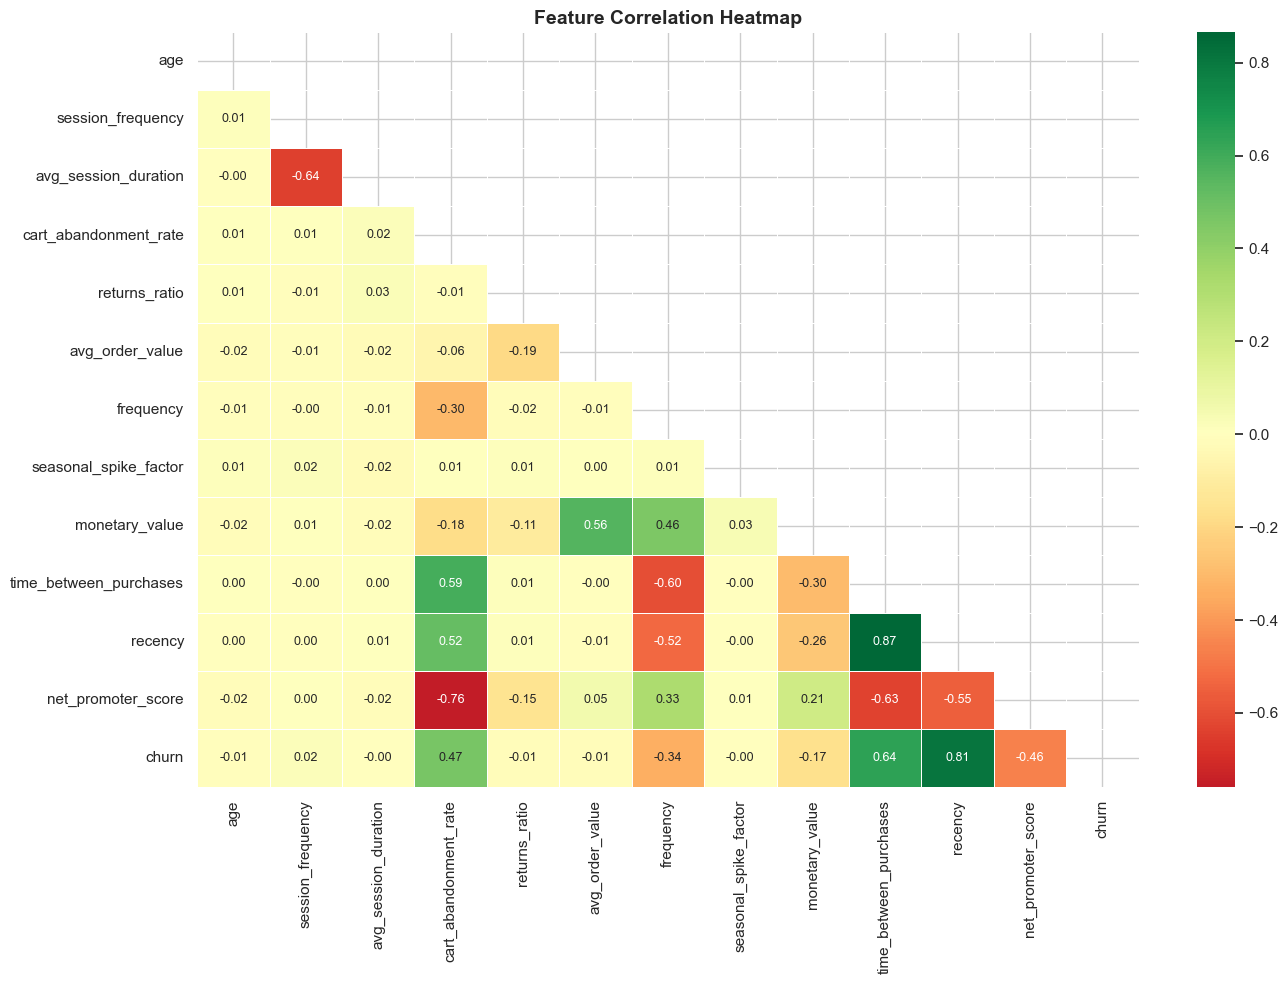

Strong churn correlations:
recency                   0.809267
time_between_purchases    0.640026
cart_abandonment_rate     0.466533
net_promoter_score       -0.459575
frequency                -0.335402
monetary_value           -0.168182
session_frequency         0.017232
avg_order_value          -0.014534
Name: churn, dtype: float64


In [16]:
numeric_cols = ['age', 'session_frequency', 'avg_session_duration',
                'cart_abandonment_rate', 'returns_ratio', 'avg_order_value',
                'frequency', 'seasonal_spike_factor', 'monetary_value',
                'time_between_purchases', 'recency', 'net_promoter_score', 'churn']

corr = customers[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Strong churn correlations:")
print(corr['churn'].drop('churn').sort_values(key=abs, ascending=False).head(8))

## 12. Geographic Analysis

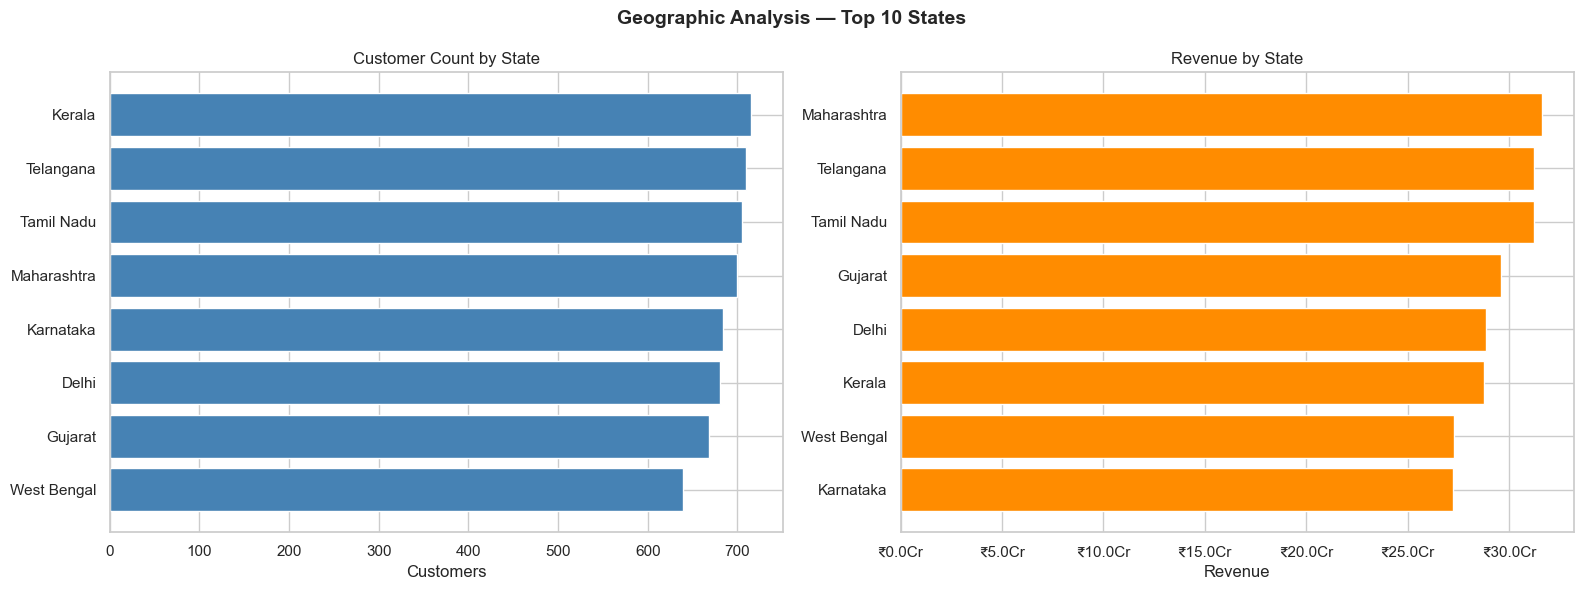

In [17]:
state_customers = customers['state'].value_counts().head(10)

txn_state = transactions.merge(customers[['customer_id','state']], on='customer_id', how='left')
state_revenue = txn_state.groupby('state')['total_amount'].sum().nlargest(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Geographic Analysis — Top 10 States', fontsize=14, fontweight='bold')

axes[0].barh(state_customers.index[::-1], state_customers.values[::-1], color='steelblue')
axes[0].set_title('Customer Count by State')
axes[0].set_xlabel('Customers')

axes[1].barh(state_revenue.index[::-1], state_revenue.values[::-1], color='darkorange')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1e7:.1f}Cr'))
axes[1].set_title('Revenue by State')
axes[1].set_xlabel('Revenue')

plt.tight_layout()
plt.savefig('../output/eda_geographic.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Year-over-Year Revenue

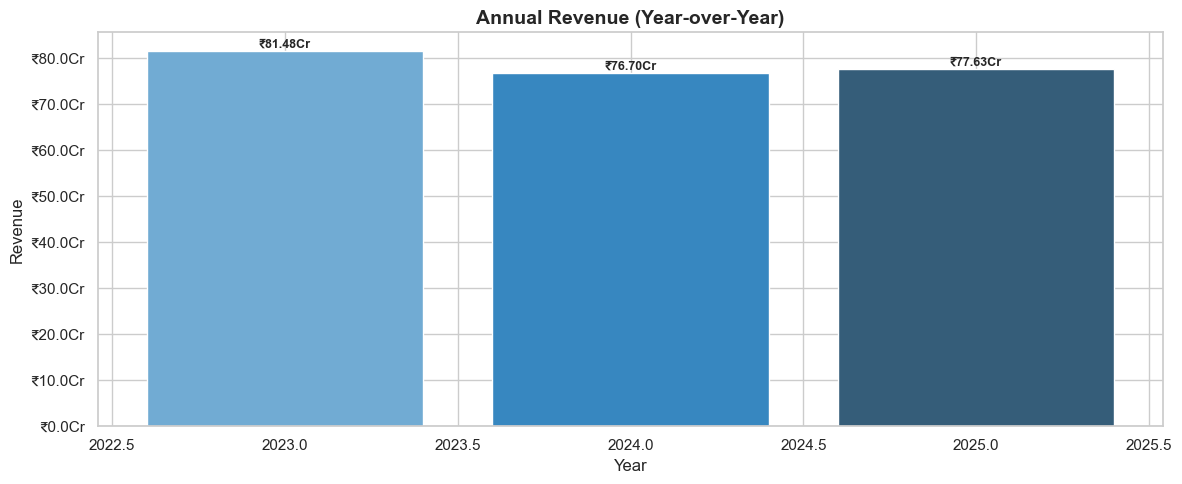

In [18]:
monthly_rev['year'] = monthly_rev['month_dt'].dt.year
yoy = monthly_rev.groupby('year')['revenue'].sum()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(yoy.index, yoy.values, color=sns.color_palette('Blues_d', len(yoy)), edgecolor='white')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1e7:.1f}Cr'))
ax.set_title('Annual Revenue (Year-over-Year)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Revenue')
for bar, val in zip(bars, yoy.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
            f'₹{val/1e7:.2f}Cr', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/eda_yoy_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Key Business Insights Summary

In [19]:
churn_rate    = customers['churn'].mean() * 100
prime_pct     = (customers['loyalty_tier'] == 'Prime').mean() * 100
total_revenue = transactions['total_amount'].sum()
avg_order     = transactions['total_amount'].mean()
avg_nps       = customers['net_promoter_score'].mean()
mobile_pct    = (customers['device_type'] == 'Mobile').mean() * 100

print("=" * 55)
print("   SMART E-COMMERCE — KEY BUSINESS INSIGHTS")
print("=" * 55)
print(f"  Total Transactions  : {len(transactions):,}")
print(f"  Total Customers     : {len(customers):,}")
print(f"  Total Products      : {len(products):,}")
print(f"  Total Revenue       : ₹{total_revenue/1e7:.2f} Cr")
print(f"  Avg Order Value     : ₹{avg_order:,.0f}")
print(f"  Churn Rate          : {churn_rate:.1f}%")
print(f"  Prime Members       : {prime_pct:.1f}%")
print(f"  Avg NPS             : {avg_nps:.1f}")
print(f"  Mobile Users        : {mobile_pct:.1f}%")
print("=" * 55)
print()
print("Top performing category:")
print(transactions.groupby('category')['total_amount'].sum().sort_values(ascending=False))


   SMART E-COMMERCE — KEY BUSINESS INSIGHTS
  Total Transactions  : 55,000
  Total Customers     : 5,500
  Total Products      : 500
  Total Revenue       : ₹235.81 Cr
  Avg Order Value     : ₹42,874
  Churn Rate          : 21.0%
  Prime Members       : 43.9%
  Avg NPS             : 40.7
  Mobile Users        : 73.6%

Top performing category:
category
Electronics       2.196722e+09
Fashion           9.256061e+07
Home & Kitchen    3.428792e+07
Sports            1.242877e+07
Beauty            1.170004e+07
Books             8.238015e+06
Grocery           2.137792e+06
Name: total_amount, dtype: float64
